## tl;dr

This notebook regenerates the complete S7C-C1 bearing-level study. The result is an **EKF baseline under a strict constant-velocity model** (`Q=0`), not a manoeuvre-capable or signal-level tracker. Comparisons use the same asynchronous events for the EKF, causal-prefix batch, and common-initial-batch/no-update methods; offline full-record batch is labelled noncausal.

## Context & Methods

The physical measurement uses the reception timestamp and solves retarded emission time from the candidate state. Availability is only the causal scheduling timestamp. Residual, Jacobian, covariance and bias use the immutable `BearingMeasurement.tangent_frame`.

### Key Assumptions

- three stationary, synchronized ENU stations; homogeneous stationary medium and known `c=343 m/s`;
- direct bearing-level observations with positive-definite anisotropic covariance;
- exact constant velocity and zero process noise; one EKF linearization per bearing;
- 24 configurations × 4 independent whole sequences = 96 independent sequences; temporal prefixes are dependent;
- chi-square NIS/NEES comparisons are local Gaussian diagnostics, not distributional claims.

In [1]:
from pathlib import Path
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from validation.retarded_ekf_study import run_retarded_ekf_study

publication_rows, sequence_rows, summary_rows = run_retarded_ekf_study()
print(f'publication rows: {len(publication_rows)}')
print(f'sequence-method rows: {len(sequence_rows)}')
print(f'aggregate rows: {len(summary_rows)}')

publication rows: 4416
sequence-method rows: 384
aggregate rows: 96


## Data

The following checks verify protocol grain, seed uniqueness, finite accepted estimates, and covariance numerics before plotting conclusions.

In [2]:
methods = sorted({row['method'] for row in sequence_rows})
assert len(publication_rows) == 4416
assert len(sequence_rows) == 384
assert len(summary_rows) == 96
assert methods == ['causal_prefix_batch', 'initial_batch_no_updates', 'offline_full_record_noncausal', 'retarded_ekf']
seed_triplets = {(row['truth_seed'], row['bearing_noise_seed'], row['delivery_seed']) for row in sequence_rows}
assert len(seed_triplets) == 96
ekf_sequences = [row for row in sequence_rows if row['method'] == 'retarded_ekf']
assert all(row['independent_unit'] == 'whole_sequence' for row in ekf_sequences)
assert all(row['time_samples_within_sequence_are_dependent'] for row in ekf_sequences)
assert max(row['maximum_covariance_symmetry_error'] for row in ekf_sequences) < 1e-12
assert min(row['minimum_covariance_eigenvalue'] for row in ekf_sequences) > 0.0
print('methods:', methods)
print('unique independent sequence seed triplets:', len(seed_triplets))

methods: ['causal_prefix_batch', 'initial_batch_no_updates', 'offline_full_record_noncausal', 'retarded_ekf']
unique independent sequence seed triplets: 96


## Results

In [3]:
def overall(method):
    rows = [row for row in sequence_rows if row['method'] == method and row['final_valid']]
    position = np.asarray([row['final_position_error_m'] for row in rows])
    velocity = np.asarray([row['final_velocity_error_mps'] for row in rows])
    coverage = np.mean([row['final_state_95_coverage'] for row in rows])
    return len(rows), np.sqrt(np.mean(position**2)), np.sqrt(np.mean(velocity**2)), coverage

print('method | valid/96 | position RMSE [m] | velocity RMSE [m/s] | final 95% state coverage')
for method in methods:
    count, position_rmse, velocity_rmse, coverage = overall(method)
    print(f'{method:30s} {count:3d}/96 {position_rmse:10.6f} {velocity_rmse:12.6f} {coverage:8.4f}')
print('EKF mean pre-update NIS:', np.mean([row['mean_measurement_nis'] for row in ekf_sequences]))
print('EKF mean time to first estimate [s]:', np.mean([row['time_to_first_estimate_s'] for row in ekf_sequences]))

method | valid/96 | position RMSE [m] | velocity RMSE [m/s] | final 95% state coverage
causal_prefix_batch             96/96   0.424832     0.186713   0.9688
initial_batch_no_updates        96/96   2.741751     0.803557   0.9688
offline_full_record_noncausal   96/96   0.424832     0.186713   0.9688
retarded_ekf                    96/96   0.424889     0.186865   0.9688
EKF mean pre-update NIS: 2.0304457670683465
EKF mean time to first estimate [s]: 1.1214246733063182


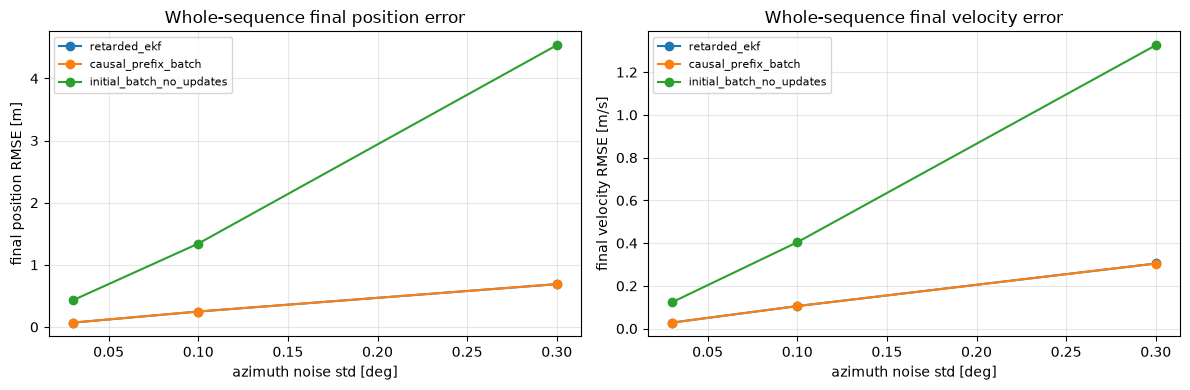

In [4]:
causal_methods = ['retarded_ekf', 'causal_prefix_batch', 'initial_batch_no_updates']
noise_levels = sorted({row['azimuth_noise_std_deg'] for row in sequence_rows})
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for method in causal_methods:
    position_rmse = []
    velocity_rmse = []
    for noise in noise_levels:
        rows = [row for row in sequence_rows if row['method'] == method and row['azimuth_noise_std_deg'] == noise and row['final_valid']]
        position_rmse.append(np.sqrt(np.mean([row['final_position_error_m']**2 for row in rows])))
        velocity_rmse.append(np.sqrt(np.mean([row['final_velocity_error_mps']**2 for row in rows])))
    axes[0].plot(noise_levels, position_rmse, marker='o', label=method)
    axes[1].plot(noise_levels, velocity_rmse, marker='o', label=method)
axes[0].set(xlabel='azimuth noise std [deg]', ylabel='final position RMSE [m]', title='Whole-sequence final position error')
axes[1].set(xlabel='azimuth noise std [deg]', ylabel='final velocity RMSE [m/s]', title='Whole-sequence final velocity error')
for axis in axes:
    axis.grid(True, alpha=0.3)
    axis.legend(fontsize=8)
plt.tight_layout()

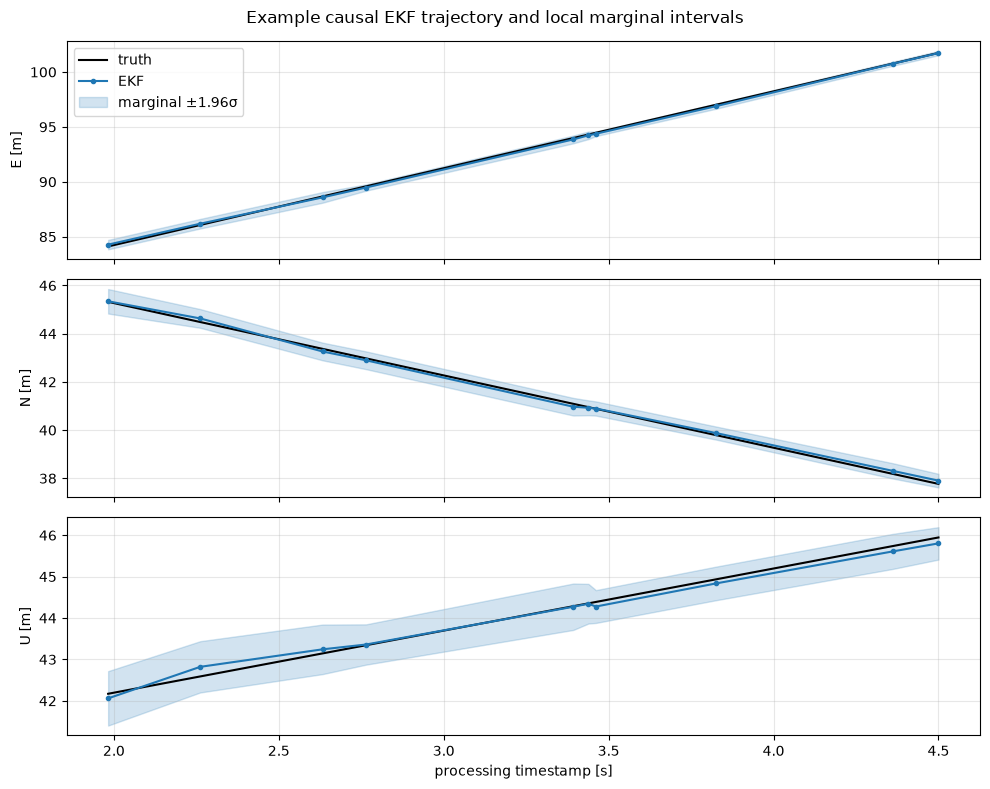

In [5]:
example = [row for row in publication_rows if row['method'] == 'retarded_ekf' and row['geometry'] == 'informative' and row['motion'] == 'uniform_oblique' and row['azimuth_noise_std_deg'] == 0.1 and row['delivery_schedule'] == 'reordered' and row['sequence_index'] == 0 and row['valid']]
times = np.asarray([row['processing_time_s'] for row in example])
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for axis_index, (coordinate, unit) in enumerate((('e', 'm'), ('n', 'm'), ('u', 'm'))):
    truth = np.asarray([row[f'truth_q_{coordinate}_m'] for row in example])
    estimate = np.asarray([row[f'estimate_q_{coordinate}_m'] for row in example])
    std = np.asarray([row[f'std_q_{coordinate}_m'] for row in example])
    axes[axis_index].plot(times, truth, color='black', label='truth')
    axes[axis_index].plot(times, estimate, color='tab:blue', marker='.', label='EKF')
    axes[axis_index].fill_between(times, estimate - 1.96*std, estimate + 1.96*std, color='tab:blue', alpha=0.2, label='marginal ±1.96σ')
    axes[axis_index].set_ylabel(f'{coordinate.upper()} [{unit}]')
    axes[axis_index].grid(True, alpha=0.3)
axes[0].legend()
axes[-1].set_xlabel('processing timestamp [s]')
fig.suptitle('Example causal EKF trajectory and local marginal intervals')
plt.tight_layout()

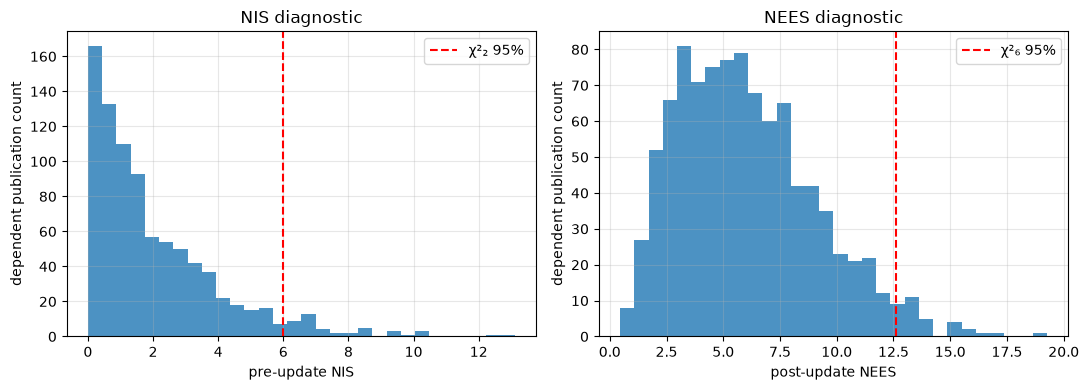

In [6]:
valid_ekf_publications = [row for row in publication_rows if row['method'] == 'retarded_ekf' and row['valid']]
update_nis = np.asarray([row['mean_update_nis'] for row in valid_ekf_publications if np.isfinite(row['mean_update_nis'])])
state_nees = np.asarray([row['state_nees'] for row in valid_ekf_publications if np.isfinite(row['state_nees'])])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(update_nis, bins=30, alpha=0.8)
axes[0].axvline(5.991464547, color='red', linestyle='--', label='χ²₂ 95%')
axes[0].set(xlabel='pre-update NIS', ylabel='dependent publication count', title='NIS diagnostic')
axes[1].hist(state_nees, bins=30, alpha=0.8)
axes[1].axvline(12.591587244, color='red', linestyle='--', label='χ²₆ 95%')
axes[1].set(xlabel='post-update NEES', ylabel='dependent publication count', title='NEES diagnostic')
for axis in axes:
    axis.legend()
    axis.grid(True, alpha=0.3)
plt.tight_layout()

## Takeaways

The numerical table above is the authoritative executed result. EKF and final causal batch should be close in this deliberately favourable strict-CV/small-noise regime, but equality is not required because EKF uses one local linearization per event. The no-update baseline isolates the benefit of later measurements. Poor coverage or large tails are retained rather than removed. Four independent sequences per configuration imply wide per-cell coverage intervals. No result here supports manoeuvre tracking, nonzero process noise, singular bearing covariance, real-audio performance, or a signal-level CRLB.